# Load And Prepare Official Swiss Labour-Market Data

This notebook pulls together the first official datasets for the project:

- BFS household survey employment table: asset `36346767`
- BFS firm survey employment table: asset `36412419`
- SECO quarterly GDP machine-readable CSV
- seasonally adjusted unemployment rate from the SNB `amarbma` cube, code `S1`, which republishes the SECO labour-market series

The output is a set of cleaned CSV files in `data/prepared/`, plus one merged quarterly panel we can discuss and refine.

## Source Notes

- BFS household survey page: <https://www.bfs.admin.ch/bfs/de/home/statistiken/arbeit-erwerb/erhebungen/ets.assetdetail.36346767.html>
- BFS firm survey page: <https://www.bfs.admin.ch/bfs/de/home/statistiken/katalog.assetdetail.36412419.html>
- SECO GDP data page: <https://www.seco.admin.ch/seco/en/home/wirtschaftslage---wirtschaftspolitik/Wirtschaftslage/bip-quartalsschaetzungen-/daten.html>
- In the SECO machine-readable GDP file, `csa` means seasonally and calendar adjusted, `nasa` means sport event adjusted, and `cssa` means seasonally, calendar and sport event adjusted.
- For unemployment, the notebook uses the SNB cube export because it provides a reproducible historical time series; the selected series is `S1`, the seasonally adjusted unemployment rate sourced from SECO.

In [1]:
from pathlib import Path
import sys

import pandas as pd

CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD if (CWD / 'src').exists() else CWD.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from swiss_labour_break_even.official_data import (
    build_quarterly_panel,
    download_raw_data,
    load_firm_employment_quarterly,
    load_household_employment_quarterly,
    load_seco_gdp_quarterly,
    load_unemployment_monthly,
    save_prepared_tables,
    seasonally_adjust_household_employment,
    splice_household_sa_series,
)

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)

RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
PREPARED_DIR = PROJECT_ROOT / 'data' / 'prepared'

def ensure_prepared_objects():
    global household, firm, unemployment, gdp, panel
    if 'household' not in globals() and (PREPARED_DIR / 'household_employment_quarterly.csv').exists():
        household = pd.read_csv(PREPARED_DIR / 'household_employment_quarterly.csv', parse_dates=['date'])
    if 'firm' not in globals() and (PREPARED_DIR / 'firm_employment_quarterly.csv').exists():
        firm = pd.read_csv(PREPARED_DIR / 'firm_employment_quarterly.csv', parse_dates=['date'])
    if 'unemployment' not in globals() and (PREPARED_DIR / 'unemployment_monthly_sa.csv').exists():
        unemployment = pd.read_csv(PREPARED_DIR / 'unemployment_monthly_sa.csv', parse_dates=['date'])
    if 'gdp' not in globals() and (PREPARED_DIR / 'seco_gdp_quarterly_selected.csv').exists():
        gdp = pd.read_csv(PREPARED_DIR / 'seco_gdp_quarterly_selected.csv', parse_dates=['date'])
    if 'panel' not in globals() and (PREPARED_DIR / 'labour_market_quarterly_merged.csv').exists():
        panel = pd.read_csv(PREPARED_DIR / 'labour_market_quarterly_merged.csv', parse_dates=['date'])

ensure_prepared_objects()

In [2]:
# Re-download the current source files when needed.
# Comment this out if you want to work offline with the cached files.
raw_files = download_raw_data(RAW_DIR)
raw_files

{'household_xlsx': PosixPath('/Users/christianhepenstrick/codex_projects/swiss-labour-break-even-rates/data/raw/bfs_household_ets_36346767.xlsx'),
 'firm_xlsx': PosixPath('/Users/christianhepenstrick/codex_projects/swiss-labour-break-even-rates/data/raw/bfs_firm_besta_36412419.xlsx'),
 'gdp_csv': PosixPath('/Users/christianhepenstrick/codex_projects/swiss-labour-break-even-rates/data/raw/seco_gdp_ch_seco_gdp.csv'),
 'unemployment_csv': PosixPath('/Users/christianhepenstrick/codex_projects/swiss-labour-break-even-rates/data/raw/snb_amarbma_unemployment.csv')}

In [3]:
household = load_household_employment_quarterly(RAW_DIR / 'bfs_household_ets_36346767.xlsx')
firm = load_firm_employment_quarterly(RAW_DIR / 'bfs_firm_besta_36412419.xlsx')
unemployment = load_unemployment_monthly(RAW_DIR / 'snb_amarbma_unemployment.csv')
gdp = load_seco_gdp_quarterly(RAW_DIR / 'seco_gdp_ch_seco_gdp.csv')
household = splice_household_sa_series(seasonally_adjust_household_employment(household))

panel = build_quarterly_panel(
    household=household,
    firm=firm,
    unemployment_monthly=unemployment,
    gdp=gdp,
)

written = save_prepared_tables(
    output_dir=PREPARED_DIR,
    household=household,
    firm=firm,
    unemployment_monthly=unemployment,
    gdp=gdp,
    panel=panel,
)
written

{'household': PosixPath('/Users/christianhepenstrick/codex_projects/swiss-labour-break-even-rates/data/prepared/household_employment_quarterly.csv'),
 'firm': PosixPath('/Users/christianhepenstrick/codex_projects/swiss-labour-break-even-rates/data/prepared/firm_employment_quarterly.csv'),
 'unemployment': PosixPath('/Users/christianhepenstrick/codex_projects/swiss-labour-break-even-rates/data/prepared/unemployment_monthly_sa.csv'),
 'gdp': PosixPath('/Users/christianhepenstrick/codex_projects/swiss-labour-break-even-rates/data/prepared/seco_gdp_quarterly_selected.csv'),
 'panel': PosixPath('/Users/christianhepenstrick/codex_projects/swiss-labour-break-even-rates/data/prepared/labour_market_quarterly_merged.csv')}

In [4]:
summary = pd.DataFrame(
    [
        {
            'table': 'household employment',
            'start': household['date'].min(),
            'end': household['date'].max(),
            'rows': len(household),
        },
        {
            'table': 'firm employment',
            'start': firm['date'].min(),
            'end': firm['date'].max(),
            'rows': len(firm),
        },
        {
            'table': 'unemployment monthly sa',
            'start': unemployment['date'].min(),
            'end': unemployment['date'].max(),
            'rows': len(unemployment),
        },
        {
            'table': 'gdp quarterly',
            'start': gdp['date'].min(),
            'end': gdp['date'].max(),
            'rows': len(gdp),
        },
        {
            'table': 'merged quarterly panel',
            'start': panel['date'].min(),
            'end': panel['date'].max(),
            'rows': len(panel),
        },
    ]
)
summary

,table,start,end,rows
0,household employment,1975-01-01,2025-10-01,204
1,firm employment,1991-07-01,2025-10-01,138
2,unemployment monthly sa,1970-01-01,2026-04-01,676
3,gdp quarterly,1980-01-01,2026-01-01,185
4,merged quarterly panel,1970-01-01,2026-04-01,226


In [5]:
ensure_prepared_objects()
household.tail()

,date,household_employment_total,household_employment_total_sa,household_employment_total_sa_stl,household_employment_seasonal_factor_stl,household_sa_gap_official_vs_stl,household_sa_gap_pct_official_vs_stl,household_employment_total_sa_stl_chained,household_employment_total_sa_spliced_chain,household_employment_total_sa_spliced
199,2024-10-01,5387.298065,5355.939119,5361.541902,1.004804,-5.602783,0.104609,5384.631935,5355.939119,5355.939119
200,2025-01-01,5342.961600,5369.163615,5358.708635,0.997061,10.454979,-0.194723,5381.786467,5369.163615,5369.163615
201,2025-04-01,5361.883606,5367.864830,5363.561169,0.999687,4.303660,-0.080175,5386.659899,5367.864830,5367.864830
202,2025-07-01,5364.069755,5363.098775,5369.200092,0.999044,-6.101317,0.113765,5392.323106,5363.098775,5363.098775
203,2025-10-01,5391.586925,5361.680753,5373.985244,1.003275,-12.304491,0.229489,5397.128866,5361.680753,5361.680753


In [6]:
ensure_prepared_objects()
firm.tail()

,date,firm_employment_total,firm_employment_total_sa
133,2024-10-01,5.535445e+06,5.523949e+06
134,2025-01-01,5.511285e+06,5.529964e+06
135,2025-04-01,5.515476e+06,5.521289e+06
136,2025-07-01,5.531816e+06,5.519483e+06
137,2025-10-01,5.544106e+06,5.532164e+06


In [7]:
ensure_prepared_objects()
unemployment.tail(12)

,date,unemployment_rate_sa
664,2025-05-01,2.796583
665,2025-06-01,2.874136
666,2025-07-01,2.912339
667,2025-08-01,2.930143
668,2025-09-01,2.965399
669,2025-10-01,2.966790
670,2025-11-01,2.954564
671,2025-12-01,2.966156
672,2026-01-01,2.937998
673,2026-02-01,2.969798


In [8]:
ensure_prepared_objects()
gdp.tail()

,date,gdp_nom_csa,gdp_nom_cssa,gdp_nom_nasa,gdp_real_csa,gdp_real_cssa,gdp_real_nasa
180,2025-01-01,217887.444025,218079.535693,216314.719639,202350.686119,202529.080568,200295.059403
181,2025-04-01,217908.348490,218116.614770,217816.548308,202640.520413,202834.225656,202487.810125
182,2025-07-01,216156.403587,216383.110060,215620.434075,201780.955541,201992.636722,200925.633613
183,2025-10-01,215833.523092,216080.937852,218917.254859,202217.968431,202449.837691,206000.265029
184,2026-01-01,218742.230456,218513.461652,216396.532673,203544.329487,203331.517669,200857.665641


In [9]:
ensure_prepared_objects()
panel.tail(12)

,date,household_employment_total,household_employment_total_sa,household_employment_total_sa_stl,household_employment_seasonal_factor_stl,household_sa_gap_official_vs_stl,household_sa_gap_pct_official_vs_stl,household_employment_total_sa_stl_chained,household_employment_total_sa_spliced_chain,household_employment_total_sa_spliced,firm_employment_total,firm_employment_total_sa,unemployment_rate_sa_qavg,unemployment_rate_sa_qend,gdp_nom_csa,gdp_nom_cssa,gdp_nom_nasa,gdp_real_csa,gdp_real_cssa,gdp_real_nasa
214,2023-07-01,5310.767830,5305.626502,5308.873496,1.000357,-3.246994,0.061199,5331.736708,5305.626502,5305.626502,5.468726e+06,5.454705e+06,1.997654,2.022485,208437.860627,208783.869559,207639.423256,196860.117489,197186.986784,195812.249412
215,2023-10-01,5357.708967,5324.141373,5324.069689,1.006318,0.071684,-0.001346,5346.998344,5324.141373,5324.141373,5.491236e+06,5.480449e+06,2.088575,2.126669,209356.192596,209721.584888,212104.371038,197532.535455,197877.352187,201108.896311
216,2024-01-01,5305.286295,5333.069778,5322.310120,0.996801,10.759658,-0.201754,5345.231198,5333.069778,5333.069778,5.482784e+06,5.502035e+06,2.203145,2.228144,210657.036891,210834.456793,208994.890761,197544.756222,197711.128833,195234.154571
217,2024-04-01,5331.103723,5339.358864,5343.034778,0.997767,-3.675914,0.068846,5366.045108,5339.358864,5339.358864,5.496263e+06,5.501791e+06,2.307730,2.367874,213115.463543,212934.010252,212978.874251,199472.816774,199302.936675,199335.547094
218,2024-07-01,5344.871090,5342.230547,5346.422278,0.999710,-4.191731,0.078464,5369.447197,5342.230547,5342.230547,5.528994e+06,5.515749e+06,2.473501,2.520977,214845.491029,214303.260877,213490.722678,200328.469054,199822.822190,198884.216047
219,2024-10-01,5387.298065,5355.939119,5361.541902,1.004804,-5.602783,0.104609,5384.631935,5355.939119,5355.939119,5.535445e+06,5.523949e+06,2.575298,2.593511,215593.368754,215633.921800,217986.786593,200725.019518,200762.734941,203790.500949
220,2025-01-01,5342.961600,5369.163615,5358.708635,0.997061,10.454979,-0.194723,5381.786467,5369.163615,5369.163615,5.511285e+06,5.529964e+06,2.667243,2.720285,217887.444025,218079.535693,216314.719639,202350.686119,202529.080568,200295.059403
221,2025-04-01,5361.883606,5367.864830,5363.561169,0.999687,4.303660,-0.080175,5386.659899,5367.864830,5367.864830,5.515476e+06,5.521289e+06,2.802759,2.874136,217908.348490,218116.614770,217816.548308,202640.520413,202834.225656,202487.810125
222,2025-07-01,5364.069755,5363.098775,5369.200092,0.999044,-6.101317,0.113765,5392.323106,5363.098775,5363.098775,5.531816e+06,5.519483e+06,2.935960,2.965399,216156.403587,216383.110060,215620.434075,201780.955541,201992.636722,200925.633613
223,2025-10-01,5391.586925,5361.680753,5373.985244,1.003275,-12.304491,0.229489,5397.128866,5361.680753,5361.680753,5.544106e+06,5.532164e+06,2.962504,2.966156,215833.523092,216080.937852,218917.254859,202217.968431,202449.837691,206000.265029


Text(0, 0.5, 'Level')

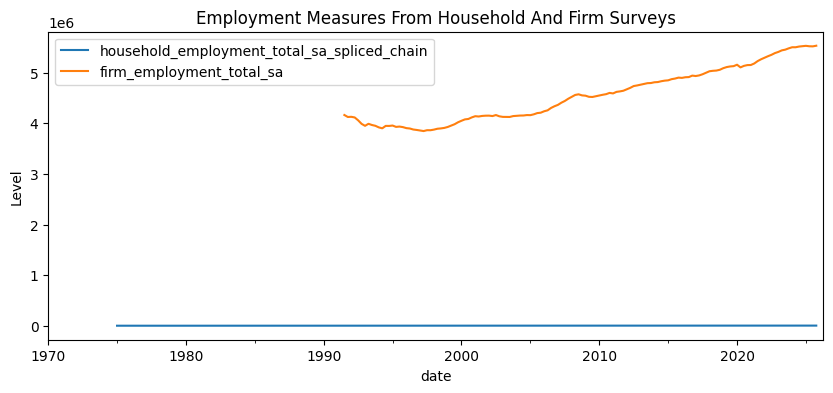

In [10]:
ensure_prepared_objects()
ax = panel.plot(
    x='date',
    y=['household_employment_total_sa_spliced_chain', 'firm_employment_total_sa'],
    figsize=(10, 4),
    title='Employment Measures From Household And Firm Surveys',
)
ax.set_ylabel('Level')

Text(0, 0.5, 'Percent')

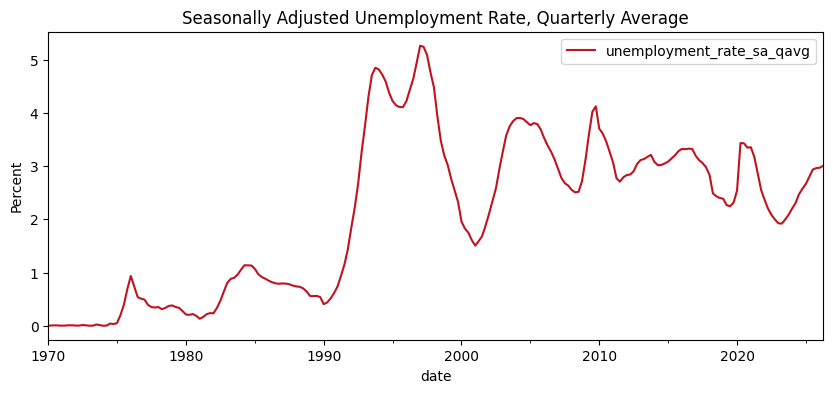

In [11]:
ensure_prepared_objects()
ax = panel.plot(
    x='date',
    y=['unemployment_rate_sa_qavg'],
    figsize=(10, 4),
    title='Seasonally Adjusted Unemployment Rate, Quarterly Average',
    color='#c1121f',
)
ax.set_ylabel('Percent')

## Back-Extended Seasonal Adjustment For The Household Series

The official BFS seasonally adjusted household-employment series only covers the recent overlap. To extend it back to the 1970s, we seasonally adjust the raw quarterly level ourselves using a log-level STL decomposition with quarterly seasonality.

The checks below compare:
- the new back-extended seasonally adjusted series against the original non-seasonally-adjusted series
- the new seasonally adjusted series against the official BFS seasonally adjusted overlap

In [12]:
ensure_prepared_objects()
household_sa = splice_household_sa_series(seasonally_adjust_household_employment(household))
household = household_sa.copy()
panel = build_quarterly_panel(
    household=household,
    firm=firm,
    unemployment_monthly=unemployment,
    gdp=gdp,
)

panel.to_csv(PREPARED_DIR / 'labour_market_quarterly_merged.csv', index=False)
household_sa.to_csv(PREPARED_DIR / 'household_employment_quarterly.csv', index=False)

household_overlap = household_sa.dropna(subset=['household_employment_total_sa']).copy()
comparison_stats = pd.DataFrame(
    {
        'metric': [
            'overlap_start',
            'overlap_end',
            'overlap_quarters',
            'splice_scale',
            'correlation',
            'mean_abs_gap_levels',
            'mean_abs_gap_pct',
            'max_abs_gap_pct',
        ],
        'value': [
            household_overlap['date'].min(),
            household_overlap['date'].max(),
            len(household_overlap),
            household_sa.attrs['splice_scale'],
            household_overlap['household_employment_total_sa'].corr(household_overlap['household_employment_total_sa_stl']),
            household_overlap['household_sa_gap_official_vs_stl'].abs().mean(),
            household_overlap['household_sa_gap_pct_official_vs_stl'].abs().mean(),
            household_overlap['household_sa_gap_pct_official_vs_stl'].abs().max(),
        ],
    }
)
comparison_stats

,metric,value
0,overlap_start,2010-01-01 00:00:00
1,overlap_end,2025-10-01 00:00:00
2,overlap_quarters,64
3,splice_scale,1.004307
4,correlation,0.999554
5,mean_abs_gap_levels,5.82346
6,mean_abs_gap_pct,0.117363
7,max_abs_gap_pct,0.489242


Text(0, 0.5, 'Level')

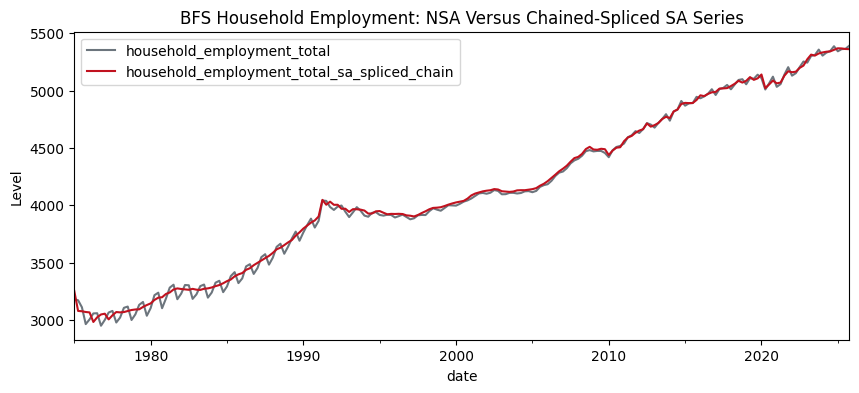

In [13]:
ax = household_sa.plot(
    x='date',
    y=['household_employment_total', 'household_employment_total_sa_spliced_chain'],
    figsize=(10, 4),
    title='BFS Household Employment: NSA Versus Chained-Spliced SA Series',
    color=['#6c757d', '#c1121f'],
)
ax.set_ylabel('Level')

Text(0, 0.5, 'Level')

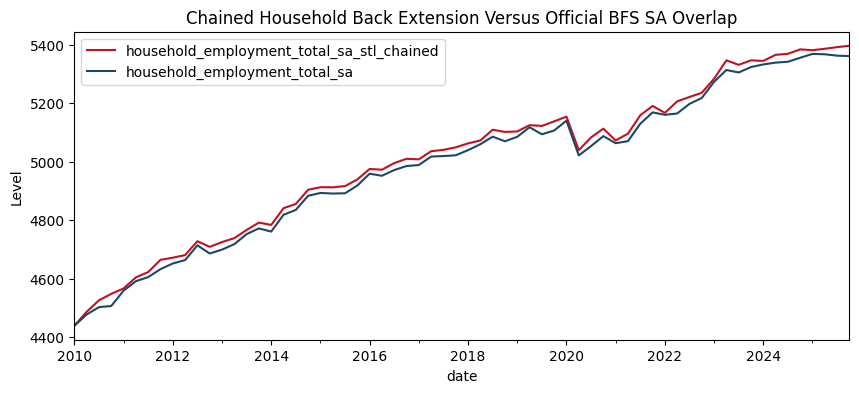

In [14]:
ax = household_overlap.plot(
    x='date',
    y=['household_employment_total_sa_stl_chained', 'household_employment_total_sa'],
    figsize=(10, 4),
    title='Chained Household Back Extension Versus Official BFS SA Overlap',
    color=['#c1121f', '#1b4965'],
)
ax.set_ylabel('Level')

In [15]:
household_overlap[['date', 'household_employment_total_sa_stl_chained', 'household_employment_total_sa', 'household_sa_gap_pct_official_vs_stl']].tail(12)

,date,household_employment_total_sa_stl_chained,household_employment_total_sa,household_sa_gap_pct_official_vs_stl
192,2023-01-01,5284.042516,5273.600510,-0.231657
193,2023-04-01,5347.072054,5313.993399,0.190999
194,2023-07-01,5331.736708,5305.626502,0.061199
195,2023-10-01,5346.998344,5324.141373,-0.001346
196,2024-01-01,5345.231198,5333.069778,-0.201754
197,2024-04-01,5366.045108,5339.358864,0.068846
198,2024-07-01,5369.447197,5342.230547,0.078464
199,2024-10-01,5384.631935,5355.939119,0.104609
200,2025-01-01,5381.786467,5369.163615,-0.194723
201,2025-04-01,5386.659899,5367.864830,-0.080175


## Household Versus Firm Employment In Growth Rates

This section compares the chained-spliced household seasonally adjusted series with the official BFS firm seasonally adjusted series using year-over-year quarterly growth rates.

In [16]:
ensure_prepared_objects()
comparison_growth = panel.loc[:, ['date', 'household_employment_total_sa_spliced_chain', 'firm_employment_total_sa']].copy()
comparison_growth = comparison_growth.dropna(subset=['household_employment_total_sa_spliced_chain', 'firm_employment_total_sa']).reset_index(drop=True)
comparison_growth['household_yoy_growth'] = 100 * comparison_growth['household_employment_total_sa_spliced_chain'].pct_change(4)
comparison_growth['firm_yoy_growth'] = 100 * comparison_growth['firm_employment_total_sa'].pct_change(4)
comparison_growth[['date', 'household_yoy_growth', 'firm_yoy_growth']].tail(12)

,date,household_yoy_growth,firm_yoy_growth
126,2023-01-01,2.187642,2.149752
127,2023-04-01,2.879396,2.159641
128,2023-07-01,2.067734,1.905313
129,2023-10-01,2.027649,1.739100
130,2024-01-01,1.127679,1.699692
131,2024-04-01,0.477333,1.126390
132,2024-07-01,0.689910,1.119116
133,2024-10-01,0.597237,0.793740
134,2025-01-01,0.676793,0.507613
135,2025-04-01,0.533884,0.354396


In [17]:
growth_overlap = comparison_growth.dropna(subset=['household_yoy_growth', 'firm_yoy_growth']).copy()
growth_stats = pd.DataFrame(
    {
        'metric': [
            'common_sample_start',
            'common_sample_end',
            'overlap_quarters',
            'correlation_yoy_growth',
            'mean_abs_growth_gap_pp',
            'max_abs_growth_gap_pp',
        ],
        'value': [
            growth_overlap['date'].min(),
            growth_overlap['date'].max(),
            len(growth_overlap),
            growth_overlap['household_yoy_growth'].corr(growth_overlap['firm_yoy_growth']),
            (growth_overlap['household_yoy_growth'] - growth_overlap['firm_yoy_growth']).abs().mean(),
            (growth_overlap['household_yoy_growth'] - growth_overlap['firm_yoy_growth']).abs().max(),
        ],
    }
)
growth_stats

,metric,value
0,common_sample_start,1992-07-01 00:00:00
1,common_sample_end,2025-10-01 00:00:00
2,overlap_quarters,134
3,correlation_yoy_growth,0.74843
4,mean_abs_growth_gap_pp,0.743117
5,max_abs_growth_gap_pp,2.767201


Text(0, 0.5, 'Percent')

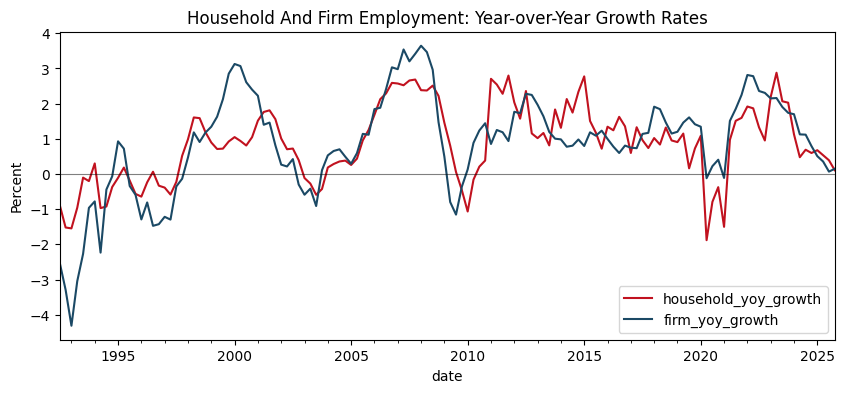

In [18]:
ax = growth_overlap.plot(
    x='date',
    y=['household_yoy_growth', 'firm_yoy_growth'],
    figsize=(10, 4),
    title='Household And Firm Employment: Year-over-Year Growth Rates',
    color=['#c1121f', '#1b4965'],
)
ax.axhline(0.0, color='black', linewidth=0.8, alpha=0.5)
ax.set_ylabel('Percent')

Text(0, 0.5, 'Percent')

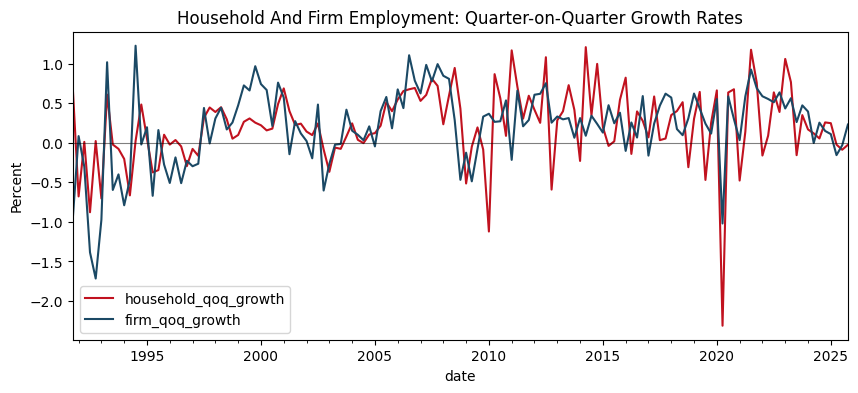

In [19]:
comparison_growth['household_qoq_growth'] = 100 * comparison_growth['household_employment_total_sa_spliced_chain'].pct_change(1)
comparison_growth['firm_qoq_growth'] = 100 * comparison_growth['firm_employment_total_sa'].pct_change(1)
qoq_overlap = comparison_growth.dropna(subset=['household_qoq_growth', 'firm_qoq_growth']).copy()

ax = qoq_overlap.plot(
    x='date',
    y=['household_qoq_growth', 'firm_qoq_growth'],
    figsize=(10, 4),
    title='Household And Firm Employment: Quarter-on-Quarter Growth Rates',
    color=['#c1121f', '#1b4965'],
)
ax.axhline(0.0, color='black', linewidth=0.8, alpha=0.5)
ax.set_ylabel('Percent')

## Final Employment Series

The final employment series is built in three steps:
1. compute q/q growth rates for the chained-spliced household SA series and the official firm SA series
2. average those q/q growth rates each quarter
3. cumulate the averaged q/q growth into a level index and rescale it so its 2019 annual average matches the 2019 annual average of the household SA series

In [20]:
final_employment = panel.loc[:, ['date', 'household_employment_total_sa_spliced_chain', 'firm_employment_total_sa']].copy()
final_employment['household_qoq_growth'] = final_employment['household_employment_total_sa_spliced_chain'].pct_change(1)
final_employment['firm_qoq_growth'] = final_employment['firm_employment_total_sa'].pct_change(1)
final_employment['avg_qoq_growth'] = final_employment[['household_qoq_growth', 'firm_qoq_growth']].mean(axis=1, skipna=False)

first_valid = final_employment['avg_qoq_growth'].first_valid_index()
final_employment['employment_blended_index'] = pd.NA
if first_valid is not None:
    final_employment.loc[first_valid, 'employment_blended_index'] = 100.0
    for i in range(first_valid + 1, len(final_employment)):
        prev = final_employment.loc[i - 1, 'employment_blended_index']
        growth = final_employment.loc[i, 'avg_qoq_growth']
        if pd.notna(prev) and pd.notna(growth):
            final_employment.loc[i, 'employment_blended_index'] = prev * (1.0 + growth)

anchor_mask = final_employment['date'].dt.year == 2019
household_2019_avg = final_employment.loc[anchor_mask, 'household_employment_total_sa_spliced_chain'].mean()
blended_2019_avg = pd.to_numeric(final_employment.loc[anchor_mask, 'employment_blended_index'], errors='coerce').mean()
scale_2019 = household_2019_avg / blended_2019_avg
final_employment['employment_blended_level'] = pd.to_numeric(final_employment['employment_blended_index'], errors='coerce') * scale_2019

panel = panel.merge(
    final_employment[['date', 'avg_qoq_growth', 'employment_blended_index', 'employment_blended_level']],
    on='date',
    how='left',
    suffixes=('', '_new'),
)
for col in ['avg_qoq_growth', 'employment_blended_index', 'employment_blended_level']:
    if f'{col}_new' in panel.columns:
        panel[col] = panel[f'{col}_new']
        panel = panel.drop(columns=[f'{col}_new'])

household = household.merge(
    final_employment[['date', 'employment_blended_level']],
    on='date',
    how='left',
    suffixes=('', '_new'),
)
if 'employment_blended_level_new' in household.columns:
    household['employment_blended_level'] = household['employment_blended_level_new']
    household = household.drop(columns=['employment_blended_level_new'])

panel.to_csv(PREPARED_DIR / 'labour_market_quarterly_merged.csv', index=False)
household.to_csv(PREPARED_DIR / 'household_employment_quarterly.csv', index=False)

pd.DataFrame({
    'metric': ['household_2019_avg', 'blended_2019_avg_before_scaling', 'scale_2019'],
    'value': [household_2019_avg, blended_2019_avg, scale_2019],
})

,metric,value
0,household_2019_avg,5101.196347
1,blended_2019_avg_before_scaling,125.259929
2,scale_2019,40.724886


In [21]:
final_employment[['date', 'household_employment_total_sa_spliced_chain', 'firm_employment_total_sa', 'avg_qoq_growth', 'employment_blended_level']].tail(12)

,date,household_employment_total_sa_spliced_chain,firm_employment_total_sa,avg_qoq_growth,employment_blended_level
214,2023-07-01,5305.626502,5.454705e+06,0.000517,5373.904858
215,2023-10-01,5324.141373,5.480449e+06,0.004105,5395.962683
216,2024-01-01,5333.069778,5.502035e+06,0.002808,5411.113813
217,2024-04-01,5339.358864,5.501791e+06,0.000567,5414.184249
218,2024-07-01,5342.230547,5.515749e+06,0.001537,5422.508447
219,2024-10-01,5355.939119,5.523949e+06,0.002026,5433.496375
220,2025-01-01,5369.163615,5.529964e+06,0.001779,5443.162468
221,2025-04-01,5367.864830,5.521289e+06,-0.000905,5438.234625
222,2025-07-01,5363.098775,5.519483e+06,-0.000607,5434.931111
223,2025-10-01,5361.680753,5.532164e+06,0.001017,5440.456119


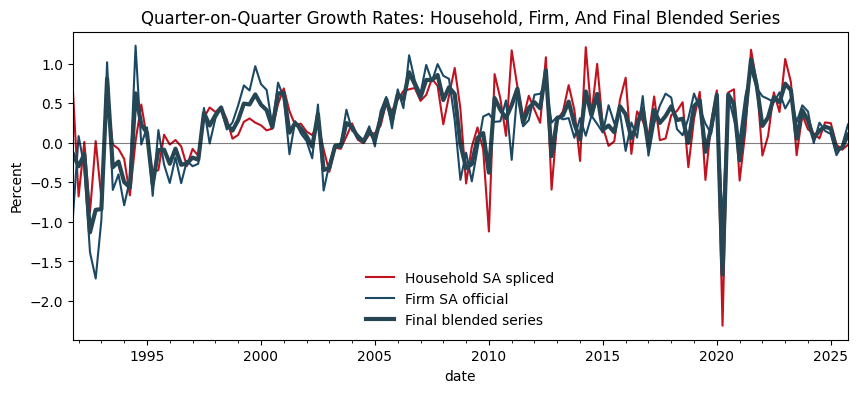

In [22]:
final_growth_plot = final_employment.loc[:, ['date', 'household_qoq_growth', 'firm_qoq_growth', 'avg_qoq_growth']].copy()
final_growth_plot['household_qoq_growth_pct'] = 100 * final_growth_plot['household_qoq_growth']
final_growth_plot['firm_qoq_growth_pct'] = 100 * final_growth_plot['firm_qoq_growth']
final_growth_plot['avg_qoq_growth_pct'] = 100 * final_growth_plot['avg_qoq_growth']
final_growth_plot = final_growth_plot.dropna(subset=['household_qoq_growth_pct', 'firm_qoq_growth_pct', 'avg_qoq_growth_pct']).copy()

ax = final_growth_plot.plot(
    x='date',
    y='household_qoq_growth_pct',
    figsize=(10, 4),
    color='#c1121f',
    linewidth=1.5,
    label='Household SA spliced',
    title='Quarter-on-Quarter Growth Rates: Household, Firm, And Final Blended Series',
)
final_growth_plot.plot(
    x='date',
    y='firm_qoq_growth_pct',
    ax=ax,
    color='#1b4965',
    linewidth=1.5,
    label='Firm SA official',
)
final_growth_plot.plot(
    x='date',
    y='avg_qoq_growth_pct',
    ax=ax,
    color='#264653',
    linewidth=3.0,
    label='Final blended series',
)
ax.axhline(0.0, color='black', linewidth=0.8, alpha=0.5)
ax.set_ylabel('Percent')
ax.legend(frameon=False)

In [23]:
final_moments = final_employment.copy()
final_moments['household_qoq_growth_pct'] = 100 * final_moments['household_qoq_growth']
final_moments['firm_qoq_growth_pct'] = 100 * final_moments['firm_qoq_growth']
final_moments['blended_qoq_growth_pct'] = 100 * final_moments['avg_qoq_growth']
moments_overlap = final_moments.dropna(subset=['household_qoq_growth_pct', 'firm_qoq_growth_pct', 'blended_qoq_growth_pct']).copy()
anchor_2019 = final_moments['date'].dt.year == 2019

moments_table = pd.DataFrame({
    'moment': ['average q/q growth', 'stdev q/q growth', 'average level in 2019'],
    'household_sa_spliced': [
        moments_overlap['household_qoq_growth_pct'].mean(),
        moments_overlap['household_qoq_growth_pct'].std(),
        final_moments.loc[anchor_2019, 'household_employment_total_sa_spliced_chain'].mean(),
    ],
    'firm_sa_official': [
        moments_overlap['firm_qoq_growth_pct'].mean(),
        moments_overlap['firm_qoq_growth_pct'].std(),
        final_moments.loc[anchor_2019, 'firm_employment_total_sa'].mean(),
    ],
    'final_blended_series': [
        moments_overlap['blended_qoq_growth_pct'].mean(),
        moments_overlap['blended_qoq_growth_pct'].std(),
        final_moments.loc[anchor_2019, 'employment_blended_level'].mean(),
    ],
})
moments_table

,moment,household_sa_spliced,firm_sa_official,final_blended_series
0,average q/q growth,0.214151,2.087167e-01,0.211434
1,stdev q/q growth,0.469629,4.809607e-01,0.408923
2,average level in 2019,5101.196347,5.112647e+06,5101.196347


Text(0, 0.5, 'Level')

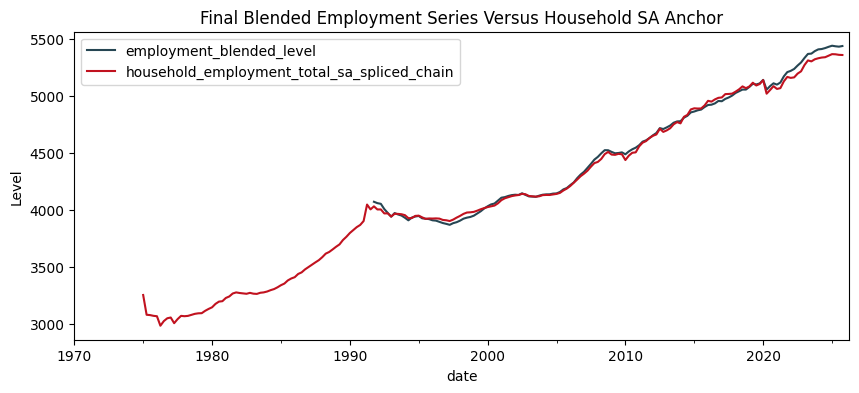

In [24]:
ax = panel.plot(
    x='date',
    y=['employment_blended_level', 'household_employment_total_sa_spliced_chain'],
    figsize=(10, 4),
    title='Final Blended Employment Series Versus Household SA Anchor',
    color=['#264653', '#c1121f'],
)
ax.set_ylabel('Level')

## Unemployment Rate

This section looks at the seasonally adjusted unemployment rate in levels and first differences.

In [25]:
ensure_prepared_objects()
unemployment_quarterly = panel.loc[:, ['date', 'unemployment_rate_sa_qavg']].copy()
unemployment_quarterly['unemployment_rate_diff'] = unemployment_quarterly['unemployment_rate_sa_qavg'].diff()
unemployment_quarterly.tail(12)

,date,unemployment_rate_sa_qavg,unemployment_rate_diff
214,2023-07-01,1.997654,0.078607
215,2023-10-01,2.088575,0.090920
216,2024-01-01,2.203145,0.114570
217,2024-04-01,2.307730,0.104585
218,2024-07-01,2.473501,0.165770
219,2024-10-01,2.575298,0.101798
220,2025-01-01,2.667243,0.091945
221,2025-04-01,2.802759,0.135516
222,2025-07-01,2.935960,0.133201
223,2025-10-01,2.962504,0.026543


Text(0, 0.5, 'Percent')

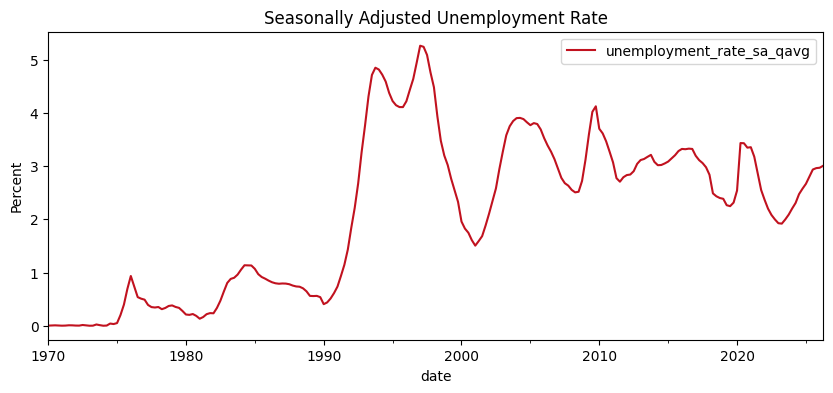

In [26]:
ax = unemployment_quarterly.plot(
    x='date',
    y='unemployment_rate_sa_qavg',
    figsize=(10, 4),
    title='Seasonally Adjusted Unemployment Rate',
    color='#c1121f',
)
ax.set_ylabel('Percent')

Text(0, 0.5, 'Percentage points')

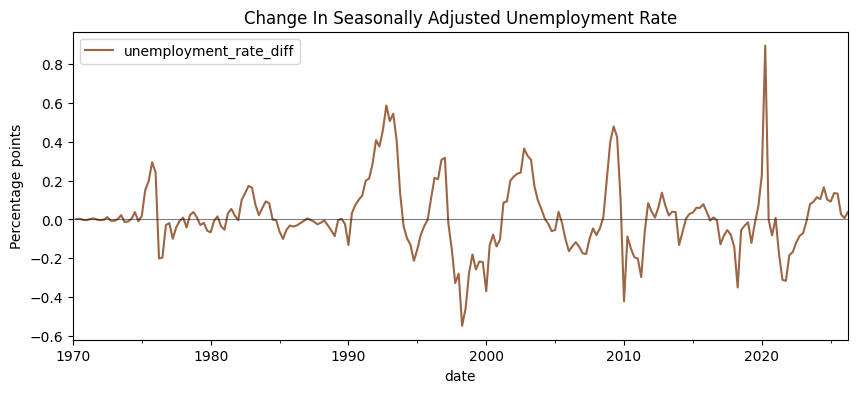

In [27]:
ax = unemployment_quarterly.plot(
    x='date',
    y='unemployment_rate_diff',
    figsize=(10, 4),
    title='Change In Seasonally Adjusted Unemployment Rate',
    color='#9c6644',
)
ax.axhline(0.0, color='black', linewidth=0.8, alpha=0.5)
ax.set_ylabel('Percentage points')

## GDP

This section focuses on the seasonally, calendar, and sport-adjusted real GDP series from SECO, shown in levels and quarter-on-quarter growth rates.

In [28]:
ensure_prepared_objects()
gdp_analysis = panel.loc[:, ['date', 'gdp_real_cssa']].copy()
gdp_analysis['gdp_real_cssa_qoq_growth'] = 100 * gdp_analysis['gdp_real_cssa'].pct_change(1)
gdp_analysis.tail(12)

,date,gdp_real_cssa,gdp_real_cssa_qoq_growth
214,2023-07-01,197186.986784,0.443710
215,2023-10-01,197877.352187,0.350107
216,2024-01-01,197711.128833,-0.084003
217,2024-04-01,199302.936675,0.805118
218,2024-07-01,199822.822190,0.260852
219,2024-10-01,200762.734941,0.470373
220,2025-01-01,202529.080568,0.879817
221,2025-04-01,202834.225656,0.150667
222,2025-07-01,201992.636722,-0.414915
223,2025-10-01,202449.837691,0.226345


Text(0, 0.5, 'Level')

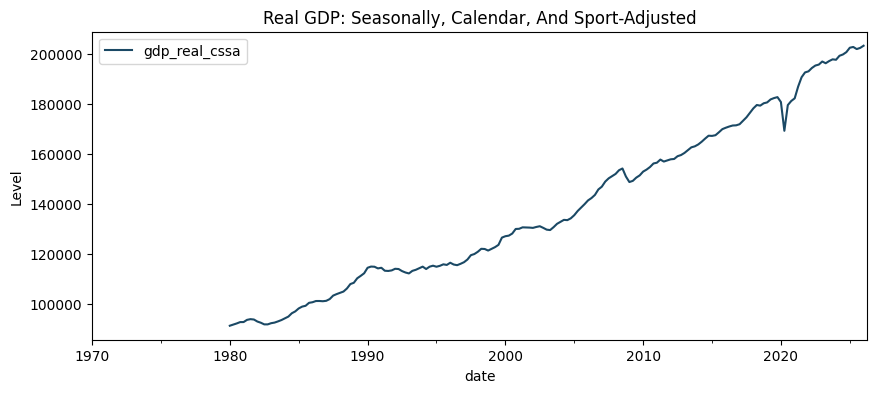

In [29]:
ax = gdp_analysis.plot(
    x='date',
    y='gdp_real_cssa',
    figsize=(10, 4),
    title='Real GDP: Seasonally, Calendar, And Sport-Adjusted',
    color='#1b4965',
)
ax.set_ylabel('Level')

Text(0, 0.5, 'Percent')

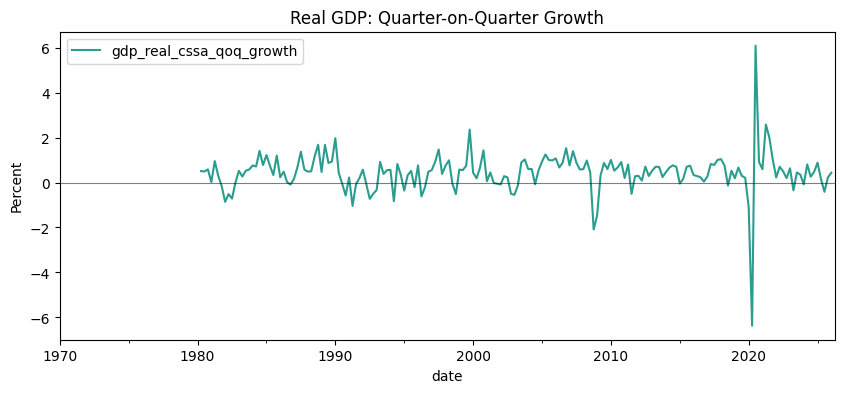

In [30]:
ax = gdp_analysis.plot(
    x='date',
    y='gdp_real_cssa_qoq_growth',
    figsize=(10, 4),
    title='Real GDP: Quarter-on-Quarter Growth',
    color='#2a9d8f',
)
ax.axhline(0.0, color='black', linewidth=0.8, alpha=0.5)
ax.set_ylabel('Percent')

## Final Dataset For Analysis

This section defines the three working variables for the analysis dataset:
- `E`: q/q growth of the constructed seasonally adjusted employment series
- `U`: first difference of the quarterly-average unemployment rate
- `Y`: q/q growth of seasonally, calendar, and sport-adjusted real GDP

In [31]:
ensure_prepared_objects()
analysis_df = panel.loc[:, ['date', 'employment_blended_level', 'unemployment_rate_sa_qavg', 'gdp_real_cssa']].copy()
analysis_df['E'] = 100 * analysis_df['employment_blended_level'].pct_change(1)
analysis_df['U'] = analysis_df['unemployment_rate_sa_qavg'].diff()
analysis_df['Y'] = 100 * analysis_df['gdp_real_cssa'].pct_change(1)
analysis_df = analysis_df.loc[:, ['date', 'E', 'U', 'Y']].dropna().reset_index(drop=True)
analysis_df.to_csv(PREPARED_DIR / 'analysis_dataset_quarterly.csv', index=False)
analysis_df.tail(12)

,date,E,U,Y
124,2023-01-01,0.745952,-0.070627,0.629883
125,2023-04-01,0.664198,-0.007797,-0.350235
126,2023-07-01,0.051737,0.078607,0.443710
127,2023-10-01,0.410462,0.090920,0.350107
128,2024-01-01,0.280786,0.114570,-0.084003
129,2024-04-01,0.056743,0.104585,0.805118
130,2024-07-01,0.153748,0.165770,0.260852
131,2024-10-01,0.202636,0.101798,0.470373
132,2025-01-01,0.177898,0.091945,0.879817
133,2025-04-01,-0.090533,0.135516,0.150667


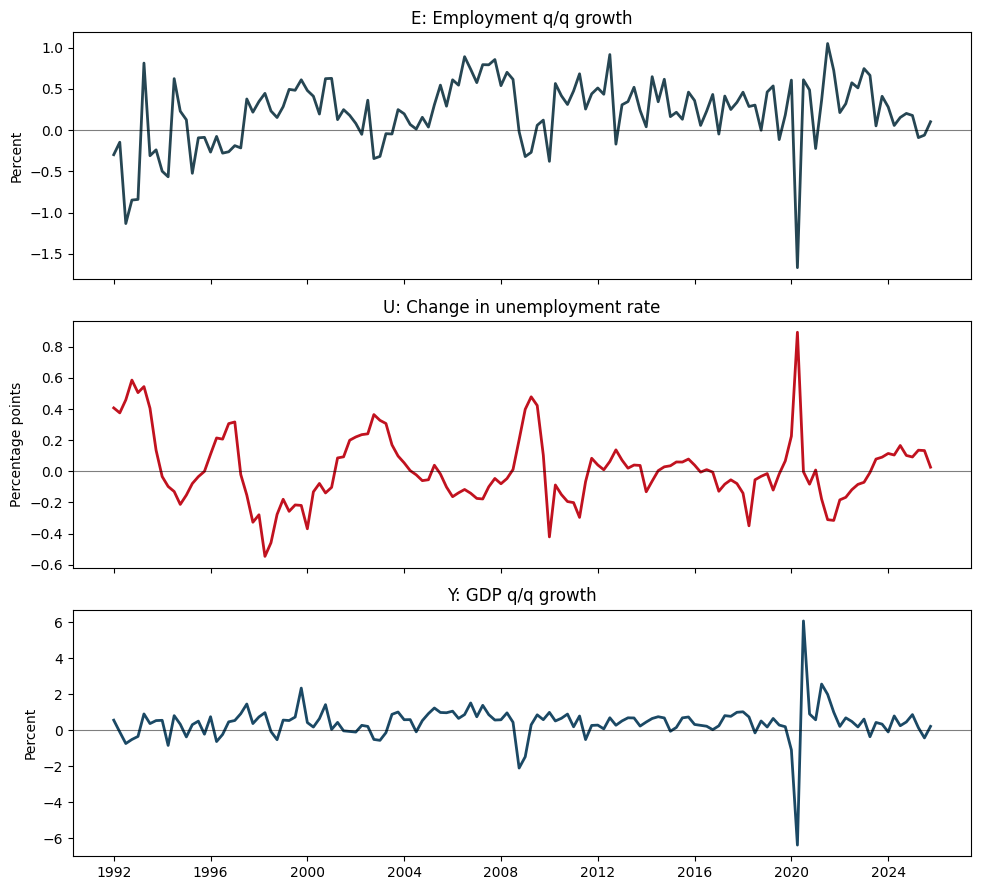

In [32]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

axes[0].plot(analysis_df['date'], analysis_df['E'], color='#264653', linewidth=2)
axes[0].axhline(0.0, color='black', linewidth=0.8, alpha=0.5)
axes[0].set_title('E: Employment q/q growth')
axes[0].set_ylabel('Percent')

axes[1].plot(analysis_df['date'], analysis_df['U'], color='#c1121f', linewidth=2)
axes[1].axhline(0.0, color='black', linewidth=0.8, alpha=0.5)
axes[1].set_title('U: Change in unemployment rate')
axes[1].set_ylabel('Percentage points')

axes[2].plot(analysis_df['date'], analysis_df['Y'], color='#1b4965', linewidth=2)
axes[2].axhline(0.0, color='black', linewidth=0.8, alpha=0.5)
axes[2].set_title('Y: GDP q/q growth')
axes[2].set_ylabel('Percent')

fig.tight_layout()

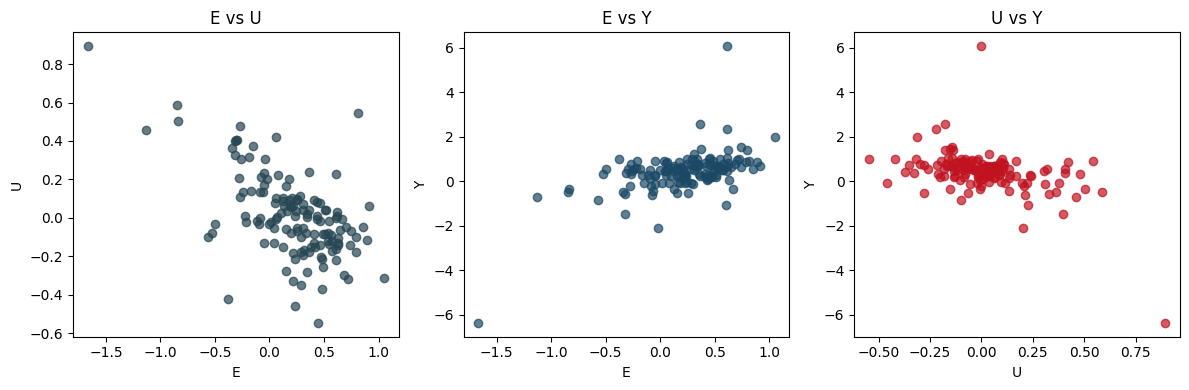

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].scatter(analysis_df['E'], analysis_df['U'], color='#264653', alpha=0.7)
axes[0].set_title('E vs U')
axes[0].set_xlabel('E')
axes[0].set_ylabel('U')

axes[1].scatter(analysis_df['E'], analysis_df['Y'], color='#1b4965', alpha=0.7)
axes[1].set_title('E vs Y')
axes[1].set_xlabel('E')
axes[1].set_ylabel('Y')

axes[2].scatter(analysis_df['U'], analysis_df['Y'], color='#c1121f', alpha=0.7)
axes[2].set_title('U vs Y')
axes[2].set_xlabel('U')
axes[2].set_ylabel('Y')

fig.tight_layout()

## Immediate Questions For The Next Step

- Should the core labour-market quantity be the household concept, the firm concept, or both?
- Do we want to work at monthly frequency and interpolate the quarterly employment block, or stay quarterly for the first model pass?
- For GDP, should the benchmark activity measure be `gdp_real_csa` or the sport-adjusted `gdp_real_cssa` series?
- Do we want to add vacancies or job-postings next so the break-even concept can be tied to market tightness rather than employment alone?